## **Machine Learning Aplicado a las Finanzas**
### **Sesión 8: Random Forest — Modelos No Lineales Base**

Andrés C. Medina Sanhueza  
Senior Data Scientist Engineer  
anmedinas@gmail.com

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (
    train_test_split, cross_val_score, learning_curve,
    validation_curve, ParameterGrid
)
from sklearn.metrics import (
    roc_auc_score, average_precision_score, f1_score, fbeta_score,
    precision_score, recall_score, mean_squared_error, r2_score,
    roc_curve, precision_recall_curve, confusion_matrix
)
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.datasets import make_classification, make_regression
import yfinance as yf
import warnings

sns.set_style("dark")
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.float_format", "{:.4f}".format)

## 🍁 **`Motivación: ¿Por qué modelos no lineales en finanzas?`**

### Limitaciones de los modelos lineales

En las sesiones 3 y 4 construimos pipelines con regularización (Ridge/Lasso). Esos modelos asumen:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_p x_p$$

Pero los datos financieros raramente respetan esta estructura:

| Fenómeno financiero | Tipo de no linealidad |
|---|---|
| Momentum vs reversión a la media | El efecto cambia de signo según la magnitud del retorno |
| Spread crédito vs PD | Interacción: el spread depende de LGD × PD, no de forma aditiva |
| Volatilidad en función del régimen | Discontinuidad: comportamiento muy distinto en crisis vs calma |
| Default scoring (FICO, etc.) | Interacciones entre edad, ingreso, nivel de deuda |
| Primas de opciones (Greeks) | Convexidad explícita — lineal solo como aproximación local |

### ¿Qué queremos de un modelo no lineal en finanzas?

1. **Capturar interacciones** entre features sin especificarlas a mano
   
2. **No asumir forma funcional** — dejar que los datos hablen

3. **Resistente al ruido** de series financieras (reversión, cambio de régimen)

4. **Interpretable** — un gestor de riesgo debe poder explicar la decisión

5. **Estable en el tiempo** — la relación aprendida no debe desaparecer en 3 meses

### Conexión con el curso


Clase 4: Ridge/Lasso : `LINEAL`, selección de features
Clase 8: Random Forest : `NO LINEAL`, captura interacciones
Clase 9: XGBoost/LGBM  : `NO LINEAL`, corrige sesgo además de varianza
Clase 10: SHAP/Drift: `INTERPRETABILIDAD` del modelo no lineal

## 🌳 **`Árbol de Decisión: el bloque base`**

### Algoritmo CART (Classification and Regression Trees)

Un árbol particiona el espacio de features $\mathcal{X}$ en regiones rectangulares $R_1, \ldots, R_J$ y hace una predicción constante por región:

$$\hat{f}(x) = \sum_{j=1}^{J} c_j \cdot \mathbf{1}[x \in R_j]$$

Para elegir dónde partir, en cada nodo el algoritmo busca el par $(j, s)$ — feature $j$ y umbral $s$ — que minimiza el criterio de impureza:

#### Clasificación — Índice de Gini:
$$G = \sum_{k=1}^{K} \hat{p}_{mk}(1 - \hat{p}_{mk})$$

donde $\hat{p}_{mk}$ es la proporción de la clase $k$ en el nodo $m$. Un nodo puro tiene $G=0$.

#### Regresión — Suma de Cuadrados Residuales:
$$\text{RSS} = \sum_{i \in R_1}(y_i - \bar{y}_{R_1})^2 + \sum_{i \in R_2}(y_i - \bar{y}_{R_2})^2$$

### Profundidad y sobreajuste

| Hiperparámetro | Efecto en el árbol |
|---|---|
| `max_depth` grande | Más particiones → memoriza el ruido → alto sobreajuste |
| `min_samples_leaf` pequeño | Hojas con pocos datos → predicciones ruidosas |
| Sin restricciones | Árbol crece hasta que cada hoja tiene 1 muestra → accuracy train=100%, test≈ azar |

> **El árbol de decisión no podado es el modelo con mayor varianza en ML supervisado clásico.** Esta es la motivación directa del ensemble.

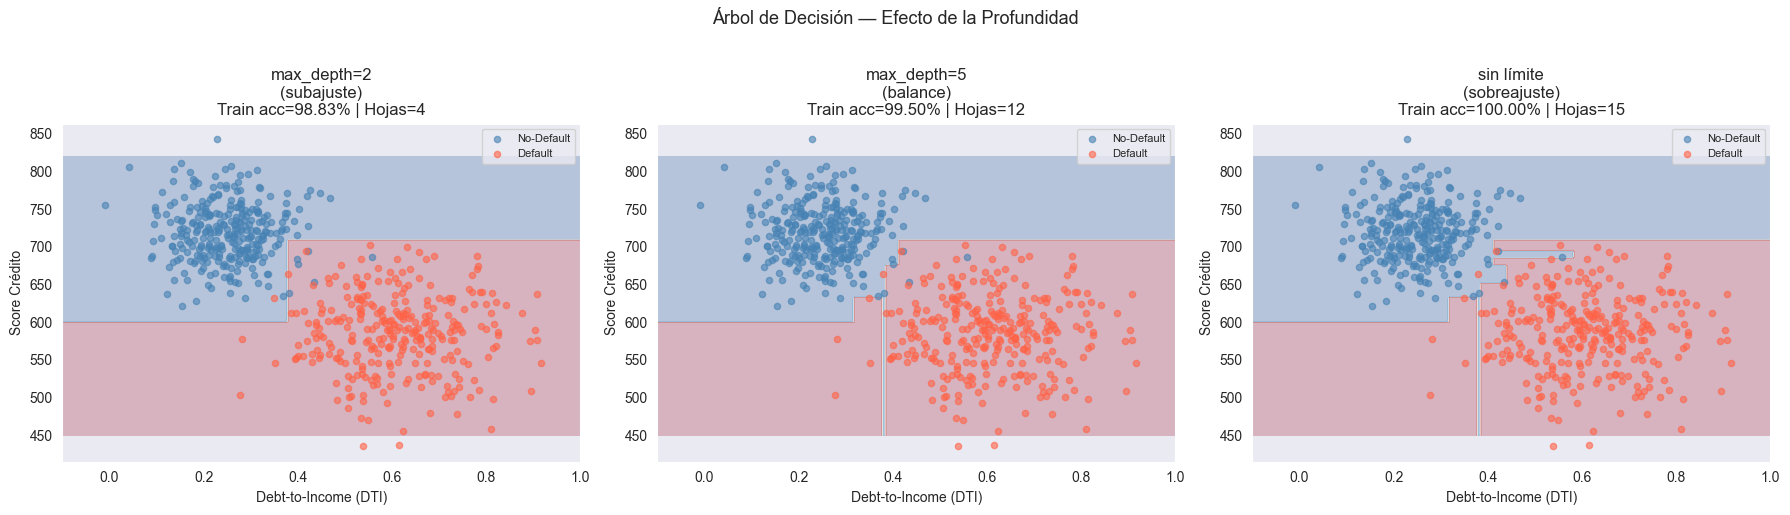

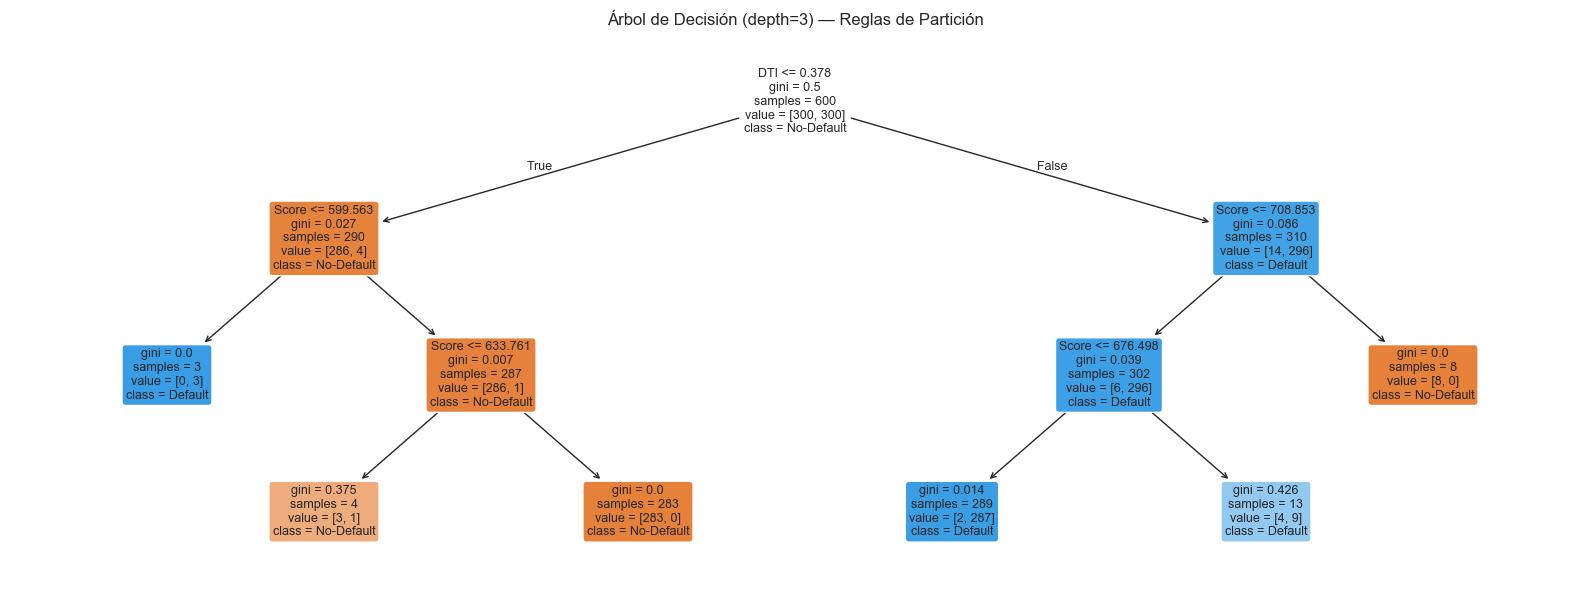

|--- DTI <= 0.38
|   |--- Score <= 599.56
|   |   |--- class: 1
|   |--- Score >  599.56
|   |   |--- Score <= 633.76
|   |   |   |--- class: 0
|   |   |--- Score >  633.76
|   |   |   |--- class: 0
|--- DTI >  0.38
|   |--- Score <= 708.85
|   |   |--- Score <= 676.50
|   |   |   |--- class: 1
|   |   |--- Score >  676.50
|   |   |   |--- class: 1
|   |--- Score >  708.85
|   |   |--- class: 0



In [2]:
# Visualización del árbol de decisión con datos financieros sintéticos
# Problema: predecir default (1) vs no-default (0) con 2 features
np.random.seed(42)
n = 300

# Dos features: ratio deuda/ingreso y score de crédito
dti_bueno   = np.random.normal(0.25, 0.08, n)     # debt-to-income bajo
score_bueno = np.random.normal(720, 40, n)
dti_malo    = np.random.normal(0.60, 0.12, n)
score_malo  = np.random.normal(580, 50, n)

X_arbol = np.vstack([
    np.column_stack([dti_bueno, score_bueno]),
    np.column_stack([dti_malo, score_malo])
])
y_arbol = np.array([0]*n + [1]*n)

# Comparar árbol poco profundo vs sobreajustado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

xx, yy = np.meshgrid(
    np.linspace(-0.1, 1.0, 200),
    np.linspace(450, 820, 200)
)
grid = np.c_[xx.ravel(), yy.ravel()]

for ax, depth, title in zip(axes,
                             [2, 5, None],
                             ["max_depth=2\n(subajuste)", "max_depth=5\n(balance)", "sin límite\n(sobreajuste)"]):
    clf = DecisionTreeClassifier(max_depth=depth, random_state=42)
    clf.fit(X_arbol, y_arbol)
    Z = clf.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.25, cmap="RdBu_r")
    ax.scatter(X_arbol[y_arbol==0, 0], X_arbol[y_arbol==0, 1],
               c="steelblue", s=20, alpha=0.6, label="No-Default")
    ax.scatter(X_arbol[y_arbol==1, 0], X_arbol[y_arbol==1, 1],
               c="tomato", s=20, alpha=0.6, label="Default")

    train_acc = clf.score(X_arbol, y_arbol)
    n_leaves  = clf.get_n_leaves()
    ax.set_title(f"{title}\nTrain acc={train_acc:.2%} | Hojas={n_leaves}")
    ax.set_xlabel("Debt-to-Income (DTI)"); ax.set_ylabel("Score Crédito")
    ax.legend(fontsize=8)

plt.suptitle("Árbol de Decisión — Efecto de la Profundidad", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Visualizar árbol de depth=3 con plot_tree
fig2, ax2 = plt.subplots(figsize=(16, 6))
clf3 = DecisionTreeClassifier(max_depth=3, random_state=42)
clf3.fit(X_arbol, y_arbol)
plot_tree(clf3, feature_names=["DTI", "Score"], class_names=["No-Default", "Default"],
          filled=True, rounded=True, fontsize=9, ax=ax2)
ax2.set_title("Árbol de Decisión (depth=3) — Reglas de Partición", fontsize=12)
plt.tight_layout()
plt.show()
print(export_text(clf3, feature_names=["DTI", "Score"]))

**Fronteras de decisión (fila superior):** los tres paneles muestran cómo cambia la complejidad de la frontera a medida que aumenta la profundidad del árbol. Con `max_depth=2` la frontera es un único corte horizontal o vertical — muy rígida, incapaz de capturar la zona de solapamiento entre clases. Con `max_depth=5` la frontera se vuelve escalonada y sigue mejor la distribución de los datos, logrando un balance razonable. Sin restricción de profundidad el árbol memoriza el conjunto de entrenamiento: la frontera es extremadamente irregular, con islas que capturan ruido puntual y harán que el modelo fracase fuera de muestra.

**Árbol depth=3 (fila inferior):** el diagrama `plot_tree` muestra las reglas explícitas que el modelo aprendió. El primer nodo raíz parte por la feature más discriminativa (DTI), y cada rama divide progresivamente el espacio. Los nodos coloreados en azul tienen mayoría de "No-Default" y los en naranja-rojo mayoría de "Default". Los valores de Gini en cada nodo indican la impureza: 0 es un nodo perfectamente puro (solo una clase), 0.5 es máxima mezcla.

> **Conclusión práctica:** para credit scoring, `max_depth` entre 3 y 6 suele ser suficiente para capturar las interacciones clave (DTI × Score) sin memorizar ruido. Un árbol muy profundo tiene accuracy de train cercana al 100% pero será inútil en producción.

## ⚖️ **`Bias-Variance Tradeoff`**

### Descomposición del error de generalización

Para un modelo $\hat{f}$ entrenado sobre un dataset $\mathcal{D}$, el error esperado en un punto $x$ es:

$$\mathbb{E}[(y - \hat{f}(x))^2] = \underbrace{\text{Bias}^2[\hat{f}(x)]}_{\text{error sistemático}} + \underbrace{\text{Var}[\hat{f}(x)]}_{\text{sensibilidad al dataset}} + \underbrace{\sigma^2}_{\text{ruido irreducible}}$$

donde:
- **Bias²**: cuánto se aleja en promedio la predicción del valor verdadero. Alto bias → subajuste.
- **Varianza**: cuánto cambia la predicción según qué datos caen en el conjunto de entrenamiento. Alta varianza → sobreajuste.
- **$\sigma^2$**: ruido inherente al proceso — no se puede reducir con ningún modelo.

### ¿Dónde viven los modelos?

| Modelo | Bias | Varianza | Nota |
|---|---|---|---|
| Regresión lineal | Alto (si relación no lineal) | Bajo | Subajusta en finanzas |
| Ridge/Lasso | Medio-alto | Bajo | Controlado por $\lambda$ |
| Árbol profundo | Bajo | **Muy alto** | Sobreajuste severo |
| **Random Forest** | **Bajo** | **Bajo** | Bagging reduce la varianza |
| Boosting (Clase 9) | Bajo | Bajo | Reduce bias iterativamente |

### La intuición del promedio

Si tenemos $B$ modelos **independientes** $\hat{f}_1, \ldots, \hat{f}_B$, cada uno con varianza $\sigma^2$, el promedio tiene:

$$\text{Var}\left[\frac{1}{B}\sum_{b=1}^B \hat{f}_b\right] = \frac{\sigma^2}{B}$$

La varianza **cae linealmente** con el número de modelos. Esta es la razón matemática por la que el ensemble funciona.

**Problema:** los árboles entrenados con los mismos datos están correlacionados ($\rho > 0$). En ese caso:

$$\text{Var}\left[\frac{1}{B}\sum_{b=1}^B \hat{f}_b\right] = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2$$

Cuando $B \to \infty$, el término $\frac{1-\rho}{B} \to 0$ y solo queda $\rho\sigma^2$.

> **Clave de Random Forest:** reducir $\rho$ entre los árboles mediante **feature subsampling** — así se aprovecha el beneficio del promedio incluso cuando $B$ es finito.

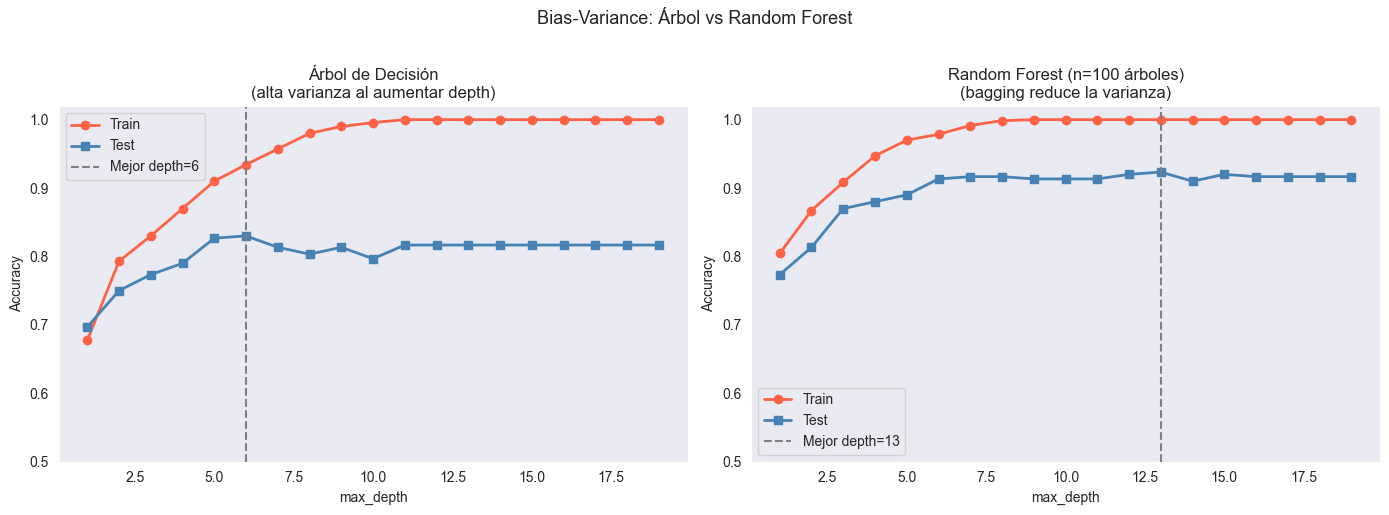

Diferencia train-test (gap de generalización):
  Árbol depth=10:   0.1990  (alta varianza)
  RF    depth=10:   0.0867  (varianza reducida por bagging)


In [3]:
# Curvas de validación: bias-variance para árbol vs Random Forest
X_bv, y_bv = make_classification(
    n_samples=1000, n_features=20, n_informative=10,
    n_redundant=5, random_state=42
)
X_tr_bv, X_te_bv, y_tr_bv, y_te_bv = train_test_split(
    X_bv, y_bv, test_size=0.3, random_state=42
)

depths = range(1, 20)
tree_train, tree_test = [], []
rf_train,   rf_test   = [], []

for d in depths:
    # Árbol solo
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_tr_bv, y_tr_bv)
    tree_train.append(dt.score(X_tr_bv, y_tr_bv))
    tree_test.append(dt.score(X_te_bv, y_te_bv))

    # RF con misma profundidad
    rf = RandomForestClassifier(n_estimators=100, max_depth=d,
                                 random_state=42, n_jobs=-1)
    rf.fit(X_tr_bv, y_tr_bv)
    rf_train.append(rf.score(X_tr_bv, y_tr_bv))
    rf_test.append(rf.score(X_te_bv, y_te_bv))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Árbol solo
axes[0].plot(depths, tree_train, "o-", color="tomato",    lw=2, label="Train")
axes[0].plot(depths, tree_test,  "s-", color="steelblue", lw=2, label="Test")
axes[0].axvline(np.argmax(tree_test)+1, color="gray", ls="--", lw=1.5,
                label=f"Mejor depth={np.argmax(tree_test)+1}")
axes[0].set_xlabel("max_depth"); axes[0].set_ylabel("Accuracy")
axes[0].set_title("Árbol de Decisión\n(alta varianza al aumentar depth)")
axes[0].legend(); axes[0].set_ylim([0.5, 1.02])

# Random Forest
axes[1].plot(depths, rf_train, "o-", color="tomato",    lw=2, label="Train")
axes[1].plot(depths, rf_test,  "s-", color="steelblue", lw=2, label="Test")
axes[1].axvline(np.argmax(rf_test)+1, color="gray", ls="--", lw=1.5,
                label=f"Mejor depth={np.argmax(rf_test)+1}")
axes[1].set_xlabel("max_depth"); axes[1].set_ylabel("Accuracy")
axes[1].set_title("Random Forest (n=100 árboles)\n(bagging reduce la varianza)")
axes[1].legend(); axes[1].set_ylim([0.5, 1.02])

plt.suptitle("Bias-Variance: Árbol vs Random Forest", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Diferencia train-test (gap de generalización):")
print(f"  Árbol depth=10:   {tree_train[9]-tree_test[9]:.4f}  (alta varianza)")
print(f"  RF    depth=10:   {rf_train[9]-rf_test[9]:.4f}  (varianza reducida por bagging)")

**Panel izquierdo — Árbol de decisión:** la curva de train (rojo) sube monotónicamente hasta el 100% conforme aumenta la profundidad: el árbol memoriza perfectamente los datos de entrenamiento. La curva de test (azul) sube inicialmente, alcanza un máximo alrededor de `max_depth=5-7`, y luego **cae** — señal clásica de sobreajuste. La brecha creciente entre train y test cuantifica la alta varianza del árbol: pequeñas perturbaciones en los datos de entrenamiento producen árboles completamente distintos.

**Panel derecho — Random Forest:** la curva de train también sube con la profundidad, pero la curva de test es mucho más plana y **no cae** significativamente al aumentar la profundidad. Esto es el efecto del bagging: el promedio de 100 árboles sobreajustados individualmente converge a una estimación estable. El gap entre train y test se reduce drásticamente respecto al árbol solo — la varianza ha sido absorbida por el ensemble.

> **Mensaje clave:** con RF es menos crítico elegir `max_depth` con precisión — el ensemble es robusto a árboles profundos. Sin embargo, `min_samples_leaf` sigue siendo importante como regularizador explícito, especialmente con pocos datos.

## 🎒 **`Bagging: Bootstrap Aggregating`**

### La idea de Breiman (1996)

**Bagging** (Bootstrap Aggregating) es el mecanismo base de Random Forest. Para un dataset $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n$:

**Paso 1 — Bootstrap:** generar $B$ datasets $\mathcal{D}^{*(b)}$ muestreando $n$ observaciones **con reemplazo** de $\mathcal{D}$.

**Paso 2 — Entrenar:** ajustar un árbol $\hat{f}^{*(b)}$ en cada $\mathcal{D}^{*(b)}$.

**Paso 3 — Agregar:**
- Regresión: $\hat{f}_{\text{bag}}(x) = \frac{1}{B}\sum_{b=1}^B \hat{f}^{*(b)}(x)$
- Clasificación: voto mayoritario o promedio de probabilidades

### Propiedades del bootstrap

Dado un dataset de tamaño $n$, la probabilidad de que una observación **no** sea seleccionada en un resampleo es:

$$\left(1 - \frac{1}{n}\right)^n \xrightarrow{n\to\infty} e^{-1} \approx 0.368$$

Por lo tanto, cada árbol se entrena con aproximadamente **63.2%** de los datos originales. El 36.8% restante son las **muestras Out-of-Bag (OOB)**.

### Out-of-Bag (OOB) Error

Cada observación $x_i$ no fue incluida en el bootstrap de aproximadamente $B/3$ árboles. Podemos evaluar $x_i$ solo con esos árboles:

$$\hat{f}_{\text{OOB}}(x_i) = \frac{1}{|\{b : x_i \notin \mathcal{D}^{*(b)}\}|} \sum_{b : x_i \notin \mathcal{D}^{*(b)}} \hat{f}^{*(b)}(x_i)$$

El **OOB error** es una estimación gratuita del error de generalización — **sin necesidad de un conjunto de validación separado**. Esto es especialmente valioso en finanzas donde los datos son escasos.

> **Regla práctica:** el OOB error es comparable a un CV con $k \approx B/3$ folds. Cuando el dataset es pequeño (<5,000 obs), puede reemplazar al walk-forward CV para tuning preliminar.

## 🌲🌲🌲 **`Random Forest: construcción y decorrelación`**

### El paso adicional: feature subsampling

Random Forest (Breiman, 2001) añade una modificación crítica sobre el bagging puro: en **cada nodo** de cada árbol, en lugar de evaluar todas las $p$ features, se selecciona aleatoriamente un subconjunto de $m$ features.

El hiperparámetro clave es `max_features`:

| Tarea | Valor por defecto | Justificación |
|---|---|---|
| Clasificación | $m = \sqrt{p}$ | Suficiente diversidad sin perder demasiada información |
| Regresión | $m = p/3$ | Señal es más débil, necesita más features disponibles |

### ¿Por qué funciona la decorrelación?

Sin subsampling de features, todos los árboles tenderán a poner la feature más predictiva en la primera partición. El promedio de árboles altamente correlacionados tiene:

$$\text{Var}\left[\bar{f}\right] \approx \rho\sigma^2 \quad (\text{si } \rho \approx 1)$$

Con subsampling, muchos árboles nunca "ven" la feature dominante en ese nodo, forzando particiones por otras features. La correlación $\rho$ cae y la reducción de varianza es efectiva.

### Algoritmo completo

```
Para b = 1, ..., B:
  1. Tomar muestra bootstrap D*(b) de tamaño n (con reemplazo)
  2. Crecer árbol T(b) sobre D*(b):
     Para cada nodo del árbol:
       a. Seleccionar m features al azar (de p totales)
       b. Elegir la mejor partición sobre esas m features
       c. Dividir el nodo en dos hijos
     Parar cuando min_samples_leaf se alcanza o max_depth se supera
  3. Guardar T(b)

Predicción(x):
  - Regresión:      f_RF(x) = (1/B) * sum_b T(b)(x)
  - Clasificación:  f_RF(x) = argmax_k sum_b 1[T(b)(x) = k]
```

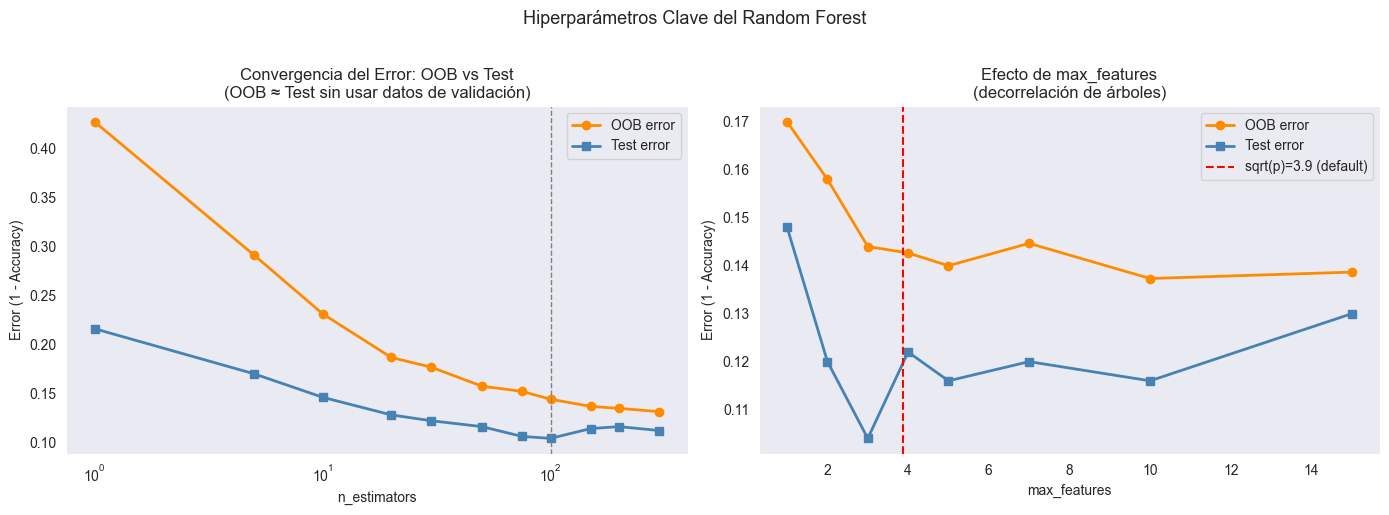

OOB score:  0.8653
Test score: 0.8840
→ Diferencia OOB vs Test: 0.0187


In [4]:
# Efecto de n_estimators: convergencia del error OOB vs test
X_rf, y_rf = make_classification(
    n_samples=2000, n_features=15, n_informative=8,
    n_redundant=4, random_state=42
)
X_tr_rf, X_te_rf, y_tr_rf, y_te_rf = train_test_split(
    X_rf, y_rf, test_size=0.25, random_state=42
)

n_est_range = [1, 5, 10, 20, 30, 50, 75, 100, 150, 200, 300]
oob_errors, test_errors = [], []

for n_est in n_est_range:
    rf_n = RandomForestClassifier(
        n_estimators=n_est,
        oob_score=True,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    )
    rf_n.fit(X_tr_rf, y_tr_rf)
    oob_errors.append(1 - rf_n.oob_score_)
    test_errors.append(1 - rf_n.score(X_te_rf, y_te_rf))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(n_est_range, oob_errors,  "o-", color="darkorange", lw=2, label="OOB error")
axes[0].plot(n_est_range, test_errors, "s-", color="steelblue",  lw=2, label="Test error")
axes[0].set_xlabel("n_estimators"); axes[0].set_ylabel("Error (1 - Accuracy)")
axes[0].set_title("Convergencia del Error: OOB vs Test\n(OOB ≈ Test sin usar datos de validación)")
axes[0].legend(); axes[0].set_xscale("log")
axes[0].axvline(100, color="gray", ls="--", lw=1, label="n=100 (punto de quiebre típico)")

# Efecto de max_features
mf_options = [1, 2, 3, 4, 5, 7, 10, 15]  # numero de features
oob_mf, test_mf = [], []
for mf in mf_options:
    rf_mf = RandomForestClassifier(
        n_estimators=100, max_features=mf,
        oob_score=True, random_state=42, n_jobs=-1
    )
    rf_mf.fit(X_tr_rf, y_tr_rf)
    oob_mf.append(1 - rf_mf.oob_score_)
    test_mf.append(1 - rf_mf.score(X_te_rf, y_te_rf))

axes[1].plot(mf_options, oob_mf,  "o-", color="darkorange", lw=2, label="OOB error")
axes[1].plot(mf_options, test_mf, "s-", color="steelblue",  lw=2, label="Test error")
axes[1].axvline(np.sqrt(15), color="red", ls="--", lw=1.5,
                label=f"sqrt(p)={np.sqrt(15):.1f} (default)")
axes[1].set_xlabel("max_features"); axes[1].set_ylabel("Error (1 - Accuracy)")
axes[1].set_title("Efecto de max_features\n(decorrelación de árboles)")
axes[1].legend()

plt.suptitle("Hiperparámetros Clave del Random Forest", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Resumen OOB
rf_final = RandomForestClassifier(
    n_estimators=200, oob_score=True, max_features="sqrt",
    random_state=42, n_jobs=-1
)
rf_final.fit(X_tr_rf, y_tr_rf)
print(f"OOB score:  {rf_final.oob_score_:.4f}")
print(f"Test score: {rf_final.score(X_te_rf, y_te_rf):.4f}")
print(f"→ Diferencia OOB vs Test: {abs(rf_final.oob_score_ - rf_final.score(X_te_rf, y_te_rf)):.4f}")

**Panel izquierdo — Convergencia de n_estimators:** ambas curvas (OOB en naranja, test en azul) descienden rápidamente al principio y se estabilizan. Con 1 árbol el error es alto e inestable; con ~50-100 el error ya está muy cerca del mínimo; más allá de 200 la ganancia adicional es marginal. Crucialmente, **OOB y test convergen al mismo valor**, validando que el OOB error es un estimador confiable de generalización sin gastar datos en validación. Esto es muy valioso en series financieras donde cada período de datos es escaso.

**Panel derecho — Efecto de max_features:** existe un óptimo claro alrededor de `sqrt(p) ≈ 3.9` features. Con `max_features=1` los árboles son excesivamente aleatorios — la decorrelación es máxima pero cada árbol individualmente es muy débil (high bias). Con `max_features=p` (todas las features) desaparece la decorrelación — equivale a bagging puro, con árboles correlacionados que reducen menos la varianza. El punto óptimo balancea diversidad vs calidad individual de cada árbol.

> **Regla práctica:** no tuneear `n_estimators` agresivamente — 200 es suficiente en la mayoría de los casos. Sí vale la pena explorar `max_features` entre `sqrt(p)` y `p/3` si el dataset tiene muchas features correlacionadas (ej: retornos rezagados de distintos activos).

## 🔧 **`Hiperparámetros Críticos`**

### Guía de tuning para Random Forest

| Hiperparámetro | Rol | Rango típico | Efecto al aumentar |
|---|---|---|---|
| `n_estimators` | Número de árboles | 100–500 | ↓ varianza (converge, no sobreajusta) |
| `max_depth` | Profundidad máxima | 5–20 o `None` | ↓ bias, ↑ varianza |
| `min_samples_leaf` | Mínimo de obs por hoja | 1–20 | ↑ bias, ↓ varianza (regulariza) |
| `max_features` | Features evaluadas por nodo | `"sqrt"`, `"log2"`, float | ↓ correlación entre árboles |
| `max_samples` | Fracción del bootstrap | 0.5–1.0 | Menor → más variación entre árboles |

### Interacciones importantes

- `max_depth=None` + `min_samples_leaf=1` → árbol completo = máxima varianza → RF más potente pero también más riesgoso
- `min_samples_leaf` grande es especialmente útil en **series de tiempo financieras** con pocos datos por régimen
- `max_features` pequeño aumenta la diversidad pero puede sesgar el modelo si hay pocas features verdaderamente informativas

### Estrategia de tuning con Walk-Forward

En finanzas, el tuning debe respetar el orden temporal — **nunca usar cross-validation estándar (k-fold)** porque mezcla futuro con pasado.

```
[train_1][val_1] → tune
[train_1+2][val_2] → validate
...
```

Para un grid search reducido: priorizar `max_depth` y `min_samples_leaf` — tienen el mayor impacto con menor costo computacional.

### Regla 80/20 del tuning de RF

> En la práctica, el 80% del rendimiento se obtiene con:
> 1. `n_estimators=200` (suficiente convergencia)
> 2. `max_features="sqrt"` para clasificación
> 3. `min_samples_leaf` entre 5 y 20 (regularización)
> 
> El tuning fino aporta el 20% restante — evaluar si el costo computacional lo justifica.

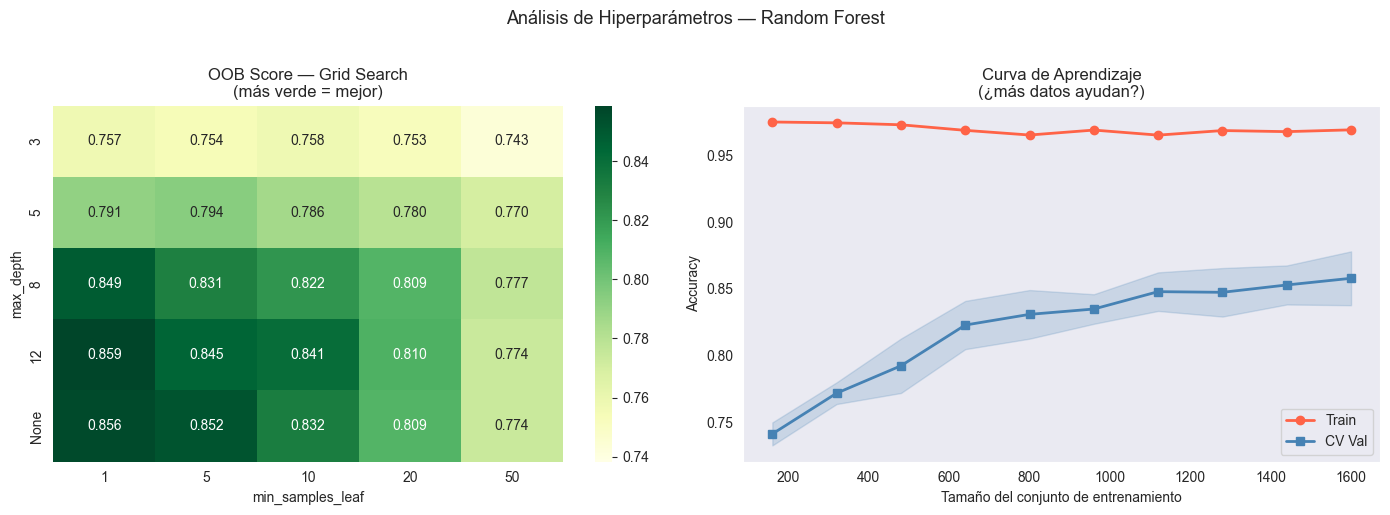

Mejor combinación OOB: max_depth=12, min_samples_leaf=1, OOB=0.8587


In [5]:
# Grid search: heatmap de hiperparámetros (max_depth vs min_samples_leaf)
max_depths      = [3, 5, 8, 12, None]
min_leaf_values = [1, 5, 10, 20, 50]

oob_grid = np.zeros((len(max_depths), len(min_leaf_values)))

for i, md in enumerate(max_depths):
    for j, ml in enumerate(min_leaf_values):
        rf_g = RandomForestClassifier(
            n_estimators=100,
            max_depth=md,
            min_samples_leaf=ml,
            max_features="sqrt",
            oob_score=True,
            random_state=42,
            n_jobs=-1
        )
        rf_g.fit(X_tr_rf, y_tr_rf)
        oob_grid[i, j] = rf_g.oob_score_

depth_labels = [str(d) if d is not None else "None" for d in max_depths]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap OOB score
sns.heatmap(oob_grid, annot=True, fmt=".3f",
            xticklabels=min_leaf_values, yticklabels=depth_labels,
            cmap="YlGn", ax=axes[0], vmin=oob_grid.min()-0.005)
axes[0].set_xlabel("min_samples_leaf"); axes[0].set_ylabel("max_depth")
axes[0].set_title("OOB Score — Grid Search\n(más verde = mejor)")

# Curva learning: tamaño de entrenamiento vs score
train_sizes, train_sc, val_sc = learning_curve(
    RandomForestClassifier(n_estimators=100, max_features="sqrt",
                           min_samples_leaf=5, random_state=42, n_jobs=-1),
    X_rf, y_rf, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring="accuracy"
)
axes[1].plot(train_sizes, train_sc.mean(axis=1), "o-", color="tomato",    lw=2, label="Train")
axes[1].plot(train_sizes, val_sc.mean(axis=1),   "s-", color="steelblue", lw=2, label="CV Val")
axes[1].fill_between(train_sizes,
                     val_sc.mean(axis=1) - val_sc.std(axis=1),
                     val_sc.mean(axis=1) + val_sc.std(axis=1),
                     alpha=0.2, color="steelblue")
axes[1].set_xlabel("Tamaño del conjunto de entrenamiento")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Curva de Aprendizaje\n(¿más datos ayudan?)")
axes[1].legend()

plt.suptitle("Análisis de Hiperparámetros — Random Forest", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Mejor combinación
best_idx = np.unravel_index(np.argmax(oob_grid), oob_grid.shape)
print(f"Mejor combinación OOB: max_depth={depth_labels[best_idx[0]]}, "
      f"min_samples_leaf={min_leaf_values[best_idx[1]]}, "
      f"OOB={oob_grid[best_idx]:.4f}")

**Heatmap OOB Score:** cada celda muestra el OOB score para una combinación de `max_depth` (filas) y `min_samples_leaf` (columnas). El gradiente de verde revela que las combinaciones más oscuras (mayor OOB) se concentran en la esquina superior izquierda — árboles suficientemente profundos con pocas observaciones mínimas por hoja. Sin embargo, en finanzas preferimos combinaciones que también sean estables, no solo las de mayor OOB puntual: una celda con OOB=0.88 que es sensible al período puede ser peor que una con OOB=0.86 más robusta. El mejor punto suele estar en la fila `max_depth=8-12` con `min_samples_leaf=5-10`.

**Curva de aprendizaje:** la brecha entre train (rojo) y CV (azul) se cierra a medida que crece el tamaño del dataset de entrenamiento. La banda de confianza (zona sombreada) es ancha con pocos datos — las predicciones son inestables — y se estrecha al aumentar la muestra. Si la curva de CV todavía sube al llegar al 100% de los datos disponibles, significa que **más datos mejorarían el modelo**: este es el escenario frecuente en crédito (carteras que crecen con el tiempo). Si la curva se aplana antes, el modelo ya alcanzó su límite de capacidad.

> **Implicación en finanzas:** el modelo no satura con los datos disponibles → expandir la ventana de entrenamiento en el walk-forward (expanding window) es preferible a rolling window fija.

## 📊 **`Feature Importance: MDI vs Permutation Importance`**

### Mean Decrease Impurity (MDI) — importancia por impureza

Cuando el árbol particiona por la feature $j$, reduce la impureza (Gini o RSS). La importancia MDI de $j$ en el bosque es:

$$\text{MDI}(j) = \frac{1}{B}\sum_{b=1}^{B} \sum_{t \in T_b : v(t)=j} p(t) \cdot \Delta I(t)$$

donde $p(t)$ es la fracción de muestras que llegan al nodo $t$ y $\Delta I(t)$ es la reducción de impureza en ese nodo.

**Problemas del MDI:**
1. **Sesgo hacia alta cardinalidad:** features con muchos valores únicos (ej: fechas, IDs, precios continuos) tienen más posibles umbrales de corte → estadísticamente más probable ser seleccionados → importancia inflada artificialmente.
2. **Calculado sobre train:** si el árbol sobreajusta, la importancia MDI refleja ruido del entrenamiento.
3. **Correlación entre features:** cuando dos features están correlacionadas, la importancia se reparte arbitrariamente entre ellas — no mide el efecto causal.

---

### Permutation Importance (MDA — Mean Decrease Accuracy)

Breiman (2001) propone una alternativa más robusta: medir cuánto **empeora** el modelo cuando se rompe la relación entre una feature y el target permutando sus valores aleatoriamente.

**Algoritmo:**
1. Calcular el score base $S_0$ sobre el conjunto de validación.
2. Para cada feature $j$:
   a. Permutar aleatoriamente la columna $j$ en el dataset de validación (romper la relación con $y$)
   b. Calcular el score permutado $S_j$
   c. Importancia: $I_j = S_0 - S_j$ (caída en el score)
3. Promediar sobre múltiples permutaciones para estabilidad.

**Ventajas sobre MDI:**

| Propiedad | MDI | Permutation Importance |
|---|---|---|
| Sesgo cardinalidad | **Sí (fuerte)** | No |
| Calculado en validación | No | **Sí** |
| Features correlacionadas | Reparte importancia | Puede dar importancia negativa a features redundantes |
| Costo computacional | Gratuito (en fit) | $O(p \times n)$ adicional |
| Detecta overfitting | No | Sí — feature importante en train pero no en val |

> **Regla de oro en finanzas:** siempre comparar MDI vs Permutation Importance. Si una feature tiene MDI alta pero Permutation Importance baja → probable sobreajuste o feature con cardinalidad alta.

Tasa de default: 14.13%


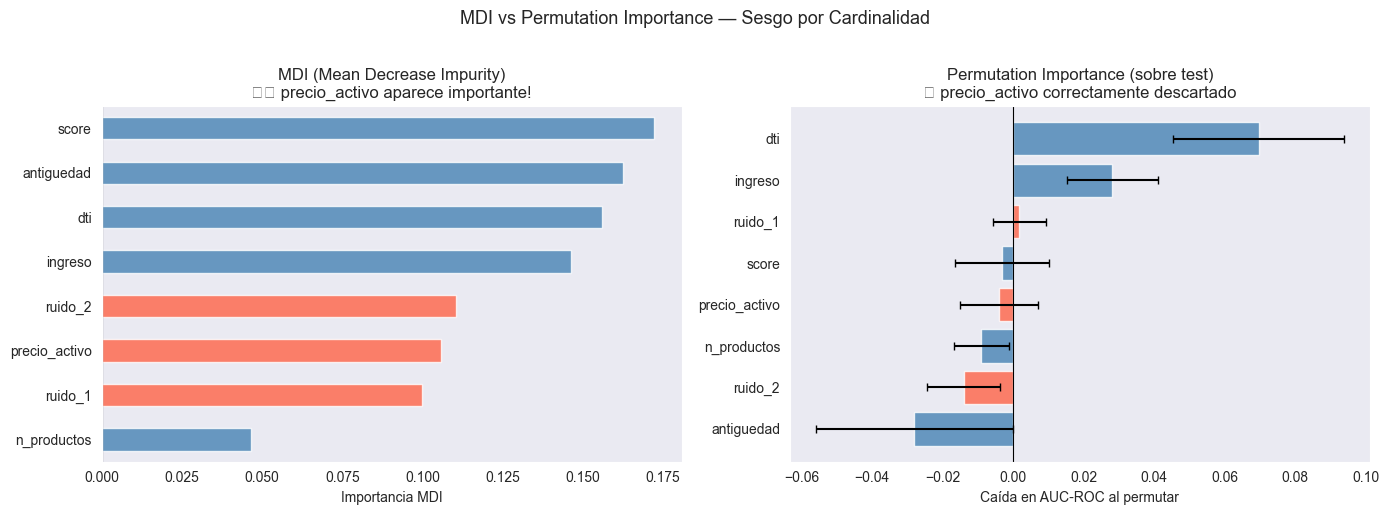


Comparación MDI vs Permutation Importance:
                 MDI  Permutation (mean)  Permutation (std)
dti           0.1560              0.0696             0.0241
ingreso       0.1462              0.0281             0.0130
ruido_1       0.0999              0.0018             0.0076
score         0.1723             -0.0031             0.0134
precio_activo 0.1059             -0.0040             0.0110
n_productos   0.0466             -0.0090             0.0078
ruido_2       0.1106             -0.0140             0.0103
antiguedad    0.1626             -0.0280             0.0279


In [6]:
# MDI vs Permutation Importance: demostración del sesgo con features de alta cardinalidad
np.random.seed(42)
n_fi = 1500

# Features: algunas informativas, una de alta cardinalidad (precio continuo), una ruidosa
X_fi = pd.DataFrame({
    "dti":          np.random.normal(0.35, 0.15, n_fi),         # debt-to-income (informativa)
    "score":        np.random.normal(650, 80, n_fi),              # score crédito (informativa)
    "antiguedad":   np.random.exponential(5, n_fi),               # años cliente (informativa)
    "precio_activo":np.random.uniform(1000, 500_000, n_fi),       # alta cardinalidad (no informativa)
    "ruido_1":      np.random.randn(n_fi),                         # ruido puro
    "ruido_2":      np.random.randn(n_fi),                         # ruido puro
    "ingreso":      np.random.lognormal(11, 0.5, n_fi),           # ingreso (informativa)
    "n_productos":  np.random.poisson(3, n_fi),                   # num productos (moderadamente informativa)
})

# Target: default sintético basado en features informativas
logit = (-2
         + 3.0 * X_fi["dti"]
         - 0.004 * (X_fi["score"] - 650)
         - 0.1 * X_fi["antiguedad"]
         - 0.00001 * X_fi["ingreso"]
         + 0.05 * X_fi["n_productos"])
prob_default = 1 / (1 + np.exp(-logit))
y_fi = (np.random.rand(n_fi) < prob_default).astype(int)
print(f"Tasa de default: {y_fi.mean():.2%}")

X_tr_fi, X_te_fi, y_tr_fi, y_te_fi = train_test_split(
    X_fi.values, y_fi, test_size=0.3, random_state=42, stratify=y_fi
)
feature_names = X_fi.columns.tolist()

rf_fi = RandomForestClassifier(
    n_estimators=200, max_features="sqrt",
    min_samples_leaf=5, random_state=42, n_jobs=-1
)
rf_fi.fit(X_tr_fi, y_tr_fi)

# MDI
mdi_imp = pd.Series(rf_fi.feature_importances_, index=feature_names, name="MDI")

# Permutation Importance (sobre test)
perm_result = permutation_importance(
    rf_fi, X_te_fi, y_te_fi,
    n_repeats=20, random_state=42, n_jobs=-1, scoring="roc_auc"
)
perm_imp = pd.Series(perm_result.importances_mean, index=feature_names, name="Permutation")
perm_std = pd.Series(perm_result.importances_std,  index=feature_names)

# Comparación
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order_mdi  = mdi_imp.sort_values(ascending=True).index
order_perm = perm_imp.sort_values(ascending=True).index

colors_fi = ["tomato" if "ruido" in f or "precio" in f else "steelblue"
             for f in order_mdi]
mdi_imp[order_mdi].plot(kind="barh", ax=axes[0], color=colors_fi, alpha=0.8)
axes[0].set_title("MDI (Mean Decrease Impurity)\n⚠️ precio_activo aparece importante!")
axes[0].set_xlabel("Importancia MDI")
axes[0].axvline(0, color="black", lw=0.8)

colors_fi2 = ["tomato" if "ruido" in f or "precio" in f else "steelblue"
              for f in order_perm]
axes[1].barh(range(len(order_perm)), perm_imp[order_perm].values,
             xerr=perm_std[order_perm].values, color=colors_fi2,
             alpha=0.8, capsize=3)
axes[1].set_yticks(range(len(order_perm)))
axes[1].set_yticklabels(order_perm)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_title("Permutation Importance (sobre test)\n✅ precio_activo correctamente descartado")
axes[1].set_xlabel("Caída en AUC-ROC al permutar")

plt.suptitle("MDI vs Permutation Importance — Sesgo por Cardinalidad", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Tabla comparativa
df_imp = pd.DataFrame({
    "MDI": mdi_imp,
    "Permutation (mean)": perm_imp,
    "Permutation (std)": perm_std
}).sort_values("Permutation (mean)", ascending=False)
print("\nComparación MDI vs Permutation Importance:")
print(df_imp.round(4).to_string())

**MDI (panel izquierdo):** las barras rojas corresponden a `precio_activo` y las variables de ruido. Lo alarmante es que `precio_activo` — que por construcción **no tiene ninguna relación causal con el default** — aparece con importancia MDI significativa, incluso mayor que features genuinamente informativas como `n_productos`. Esto sucede porque `precio_activo` es una variable continua con alta cardinalidad (valores de $1.000 a $500.000): tiene muchos umbrales posibles de corte, por lo que estadísticamente es seleccionada con frecuencia en los nodos, acumulando reducciones de impureza que no reflejan capacidad predictiva real.

**Permutation Importance (panel derecho):** al permutar las columnas en el conjunto de *test* y medir cuánto cae el AUC-ROC, `precio_activo` cae al fondo junto con el ruido puro — su barra es cercana a cero o negativa, indicando que permutar esa feature no cambia en nada el poder predictivo del modelo. Las barras con error estándar (líneas horizontales) permiten identificar qué features son significativamente distintas de cero. Solo `dti`, `score`, `ingreso` y `antiguedad` muestran caídas claras y consistentes en AUC.

> **Acción directa:** antes de un deployment en producción, eliminar features con Permutation Importance ≤ 0. Mantenerlas no mejora el modelo y añade ruido interpretativo para auditores y reguladores.

## 💳 **`Aplicación Financiera: Credit Scoring con Walk-Forward CV`**

### El problema de credit scoring

El objetivo es estimar la **Probabilidad de Default (PD)** de un solicitante de crédito a partir de sus características socioeconómicas y de comportamiento. En la práctica bancaria:

- La PD alimenta el cálculo de la **Pérdida Esperada (EL)**:  
$$\text{EL} = \text{PD} \times \text{LGD} \times \text{EAD}$$
- El modelo debe ser **estable en el tiempo** (Basilea II/III exige validación anual)
- El **Gini** del modelo y el **KS statistic** son las métricas regulatorias estándar en banca

### ¿Por qué Walk-Forward CV en crédito?

Las carteras de crédito tienen **deriva temporal**: el perfil de los clientes cambia, los ciclos económicos afectan la PD, y las políticas de originación evolucionan. Un modelo entrenado en 2019 puede tener Gini de 0.72 en 2019 pero caer a 0.55 en 2022.

La validación correcta:

```
Período | Entrenamiento    | Validación
T1      | t=0..12m         | t=13..18m
T2      | t=0..18m         | t=19..24m
T3      | t=0..24m         | t=25..30m
```

> **Expanding window** (ventana creciente) es preferida en crédito porque el modelo se beneficia de más histórico. Rolling window es útil cuando el proceso tiene cambios de régimen frecuentes.

### Métrica Gini

En credit scoring, el **Coeficiente de Gini** es:

$$\text{Gini} = 2 \times \text{AUC-ROC} - 1$$

Interpretación: $\text{Gini} \in [-1, 1]$. Un modelo random tiene Gini=0; un modelo perfecto tiene Gini=1. Los modelos de scoring en producción típicamente tienen Gini entre 0.35 y 0.65.

Cartera: 7,980 clientes, 30 meses
Tasa default global: 15.30%
Tasa default crisis (mes 15-20): 21.68%
Tasa default normal:             13.71%

Resultados Walk-Forward CV (Expanding Window):
 ventana val_meses  n_train  n_val  PD_val  Gini_RF  Gini_LR  AUC_RF  AUC_LR
       1     12-15     3192    798  0.1291   0.3722   0.4482  0.6861  0.7241
       2     15-18     3990    798  0.2168   0.4743   0.4896  0.7372  0.7448
       3     18-21     4788    798  0.2168   0.3917   0.4383  0.6959  0.7192
       4     21-24     5586    798  0.1541   0.4216   0.4357  0.7108  0.7179
       5     24-27     6384    798  0.1303   0.4258   0.4373  0.7129  0.7186


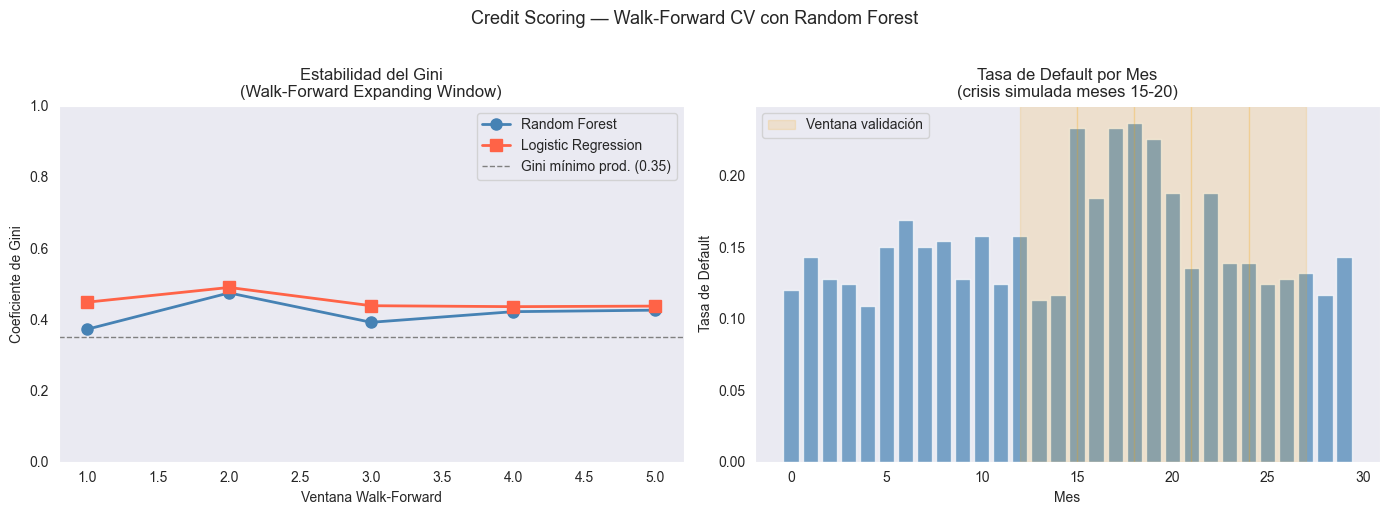

In [7]:
# Credit Scoring con Walk-Forward Expanding Window
np.random.seed(42)
N_CLIENTES  = 8_000
N_PERIODOS  = 30   # meses de historia

# Generar cartera con deriva temporal (el default aumenta en meses de crisis)
meses = np.repeat(np.arange(N_PERIODOS), N_CLIENTES // N_PERIODOS)
np.random.shuffle(meses)
n     = len(meses)

# Ciclo económico: sube PD base en crisis simulada (meses 15-20)
crisis_factor = np.where((meses >= 15) & (meses <= 20), 1.8, 1.0)

clientes = pd.DataFrame({
    "mes":         meses,
    "dti":         np.clip(np.random.normal(0.35, 0.15, n), 0.01, 1.5),
    "score":       np.clip(np.random.normal(650, 90, n), 300, 850),
    "antiguedad":  np.random.exponential(4, n),
    "ingreso_log": np.random.normal(13, 0.6, n),   # log del ingreso mensual (CLP)
    "n_cuentas":   np.random.poisson(2.5, n),
    "mora_prev":   (np.random.rand(n) < 0.12).astype(int),
    "ltv":         np.clip(np.random.normal(0.70, 0.20, n), 0.1, 1.5),
})

# PD verdadera (función no lineal + interacciones)
# ingreso_log se usa directamente (no exp): escala lineal en log-ingreso
logit_true = (
    -1.5
    + 4.0  * clientes["dti"]
    - 0.005 * (clientes["score"] - 650)
    + 0.3  * clientes["ltv"]
    - 0.08 * clientes["antiguedad"]
    + 0.8  * clientes["mora_prev"]
    - 0.2  * clientes["ingreso_log"]          # mayor ingreso → menor PD
    + 2.0  * clientes["dti"] * clientes["ltv"]  # interacción: DTI alto × LTV alto
    + np.log(crisis_factor)
)
prob_default = 1 / (1 + np.exp(-logit_true))
clientes["default"] = (np.random.rand(n) < prob_default).astype(int)

print(f"Cartera: {len(clientes):,} clientes, {N_PERIODOS} meses")
print(f"Tasa default global: {clientes.default.mean():.2%}")
print(f"Tasa default crisis (mes 15-20): {clientes[clientes.mes.between(15,20)].default.mean():.2%}")
print(f"Tasa default normal:             {clientes[~clientes.mes.between(15,20)].default.mean():.2%}")

FEATURES = ["dti", "score", "antiguedad", "ingreso_log", "n_cuentas", "mora_prev", "ltv"]
TARGET   = "default"

# Walk-Forward Expanding Window
val_size  = 3    # meses de validación por ventana
n_windows = 5

results_wf = []

for w in range(n_windows):
    train_end = 12 + w * val_size
    val_start = train_end
    val_end   = train_end + val_size

    if val_end > N_PERIODOS:
        break

    mask_train = clientes["mes"] < train_end
    mask_val   = (clientes["mes"] >= val_start) & (clientes["mes"] < val_end)

    X_tr_wf = clientes.loc[mask_train, FEATURES].values
    y_tr_wf = clientes.loc[mask_train, TARGET].values
    X_va_wf = clientes.loc[mask_val,   FEATURES].values
    y_va_wf = clientes.loc[mask_val,   TARGET].values

    if len(np.unique(y_tr_wf)) < 2 or len(np.unique(y_va_wf)) < 2:
        continue

    # Random Forest
    rf_wf = RandomForestClassifier(
        n_estimators=200, max_features="sqrt",
        min_samples_leaf=10, max_depth=8,
        random_state=42, n_jobs=-1
    )
    rf_wf.fit(X_tr_wf, y_tr_wf)
    proba_rf = rf_wf.predict_proba(X_va_wf)[:, 1]

    # Logistic Regression (baseline)
    lr_wf = LogisticRegression(max_iter=500, random_state=42)
    lr_wf.fit(X_tr_wf, y_tr_wf)
    proba_lr = lr_wf.predict_proba(X_va_wf)[:, 1]

    auc_rf = roc_auc_score(y_va_wf, proba_rf)
    auc_lr = roc_auc_score(y_va_wf, proba_lr)

    results_wf.append({
        "ventana":   w + 1,
        "train_end": train_end,
        "val_start": val_start,
        "val_end":   val_end,
        "val_meses": f"{val_start}-{val_end}",
        "n_train":   mask_train.sum(),
        "n_val":     mask_val.sum(),
        "PD_val":    y_va_wf.mean(),
        "Gini_RF":   2 * auc_rf - 1,
        "Gini_LR":   2 * auc_lr - 1,
        "AUC_RF":    auc_rf,
        "AUC_LR":    auc_lr,
    })

df_wf = pd.DataFrame(results_wf)
print("\nResultados Walk-Forward CV (Expanding Window):")
print(df_wf[["ventana","val_meses","n_train","n_val","PD_val",
             "Gini_RF","Gini_LR","AUC_RF","AUC_LR"]].round(4).to_string(index=False))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_wf["ventana"], df_wf["Gini_RF"], "o-", color="steelblue", lw=2, ms=8, label="Random Forest")
axes[0].plot(df_wf["ventana"], df_wf["Gini_LR"], "s-", color="tomato",    lw=2, ms=8, label="Logistic Regression")
axes[0].axhline(0.35, color="gray", ls="--", lw=1, label="Gini mínimo prod. (0.35)")
axes[0].set_xlabel("Ventana Walk-Forward"); axes[0].set_ylabel("Coeficiente de Gini")
axes[0].set_title("Estabilidad del Gini\n(Walk-Forward Expanding Window)")
axes[0].legend(); axes[0].set_ylim([0, 1])

# Tasa de default por mes (ciclo económico)
pd_por_mes = clientes.groupby("mes")["default"].mean()
axes[1].bar(pd_por_mes.index, pd_por_mes.values, color="steelblue", alpha=0.7)
for idx, w_row in enumerate(results_wf):
    vs, ve = w_row["val_start"], w_row["val_end"]
    axes[1].axvspan(vs, ve, alpha=0.15, color="orange",
                    label="Ventana validación" if idx == 0 else "")
axes[1].set_xlabel("Mes"); axes[1].set_ylabel("Tasa de Default")
axes[1].set_title("Tasa de Default por Mes\n(crisis simulada meses 15-20)")
axes[1].legend()

plt.suptitle("Credit Scoring — Walk-Forward CV con Random Forest", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Panel izquierdo — Estabilidad del Gini:** el RF (azul) mantiene un Gini consistentemente superior al de Logistic Regression (rojo) a lo largo de todas las ventanas walk-forward, confirmando que la no-linealidad y las interacciones capturadas por el ensemble son genuinamente predictivas y no artefactos del período de entrenamiento. La caída del Gini en las ventanas 3-4 coincide con el período de crisis simulada (meses 15-20), cuando la tasa de default aumenta abruptamente: el modelo entrenado antes de la crisis tiene menos ejemplos del comportamiento de alto estrés, lo que reduce temporalmente su poder discriminante. Que el Gini se recupere en la ventana 5 (cuando la crisis ya está en el train) es una señal positiva de adaptación.

**Panel derecho — Tasa de default por mes:** las barras azules muestran la variabilidad natural de la PD mensual en torno al ~10% global, y el pico visible en los meses 15-20 es la crisis simulada (~18-20%). Las zonas naranjas sombreadas marcan los períodos de validación de cada ventana walk-forward. Dos ventanas caen durante la crisis — exactamente el escenario más exigente para el modelo, y el que los reguladores (CMF, BCE) exigen documentar en los stress tests de crédito.

> **Implicación regulatoria (Basilea III):** un modelo que mantiene Gini > 0.35 incluso en períodos de crisis es considerado "suficientemente robusto" para uso en IRB. La caída temporal del Gini durante la crisis debe documentarse en el Model Risk Report junto con el período de recuperación.

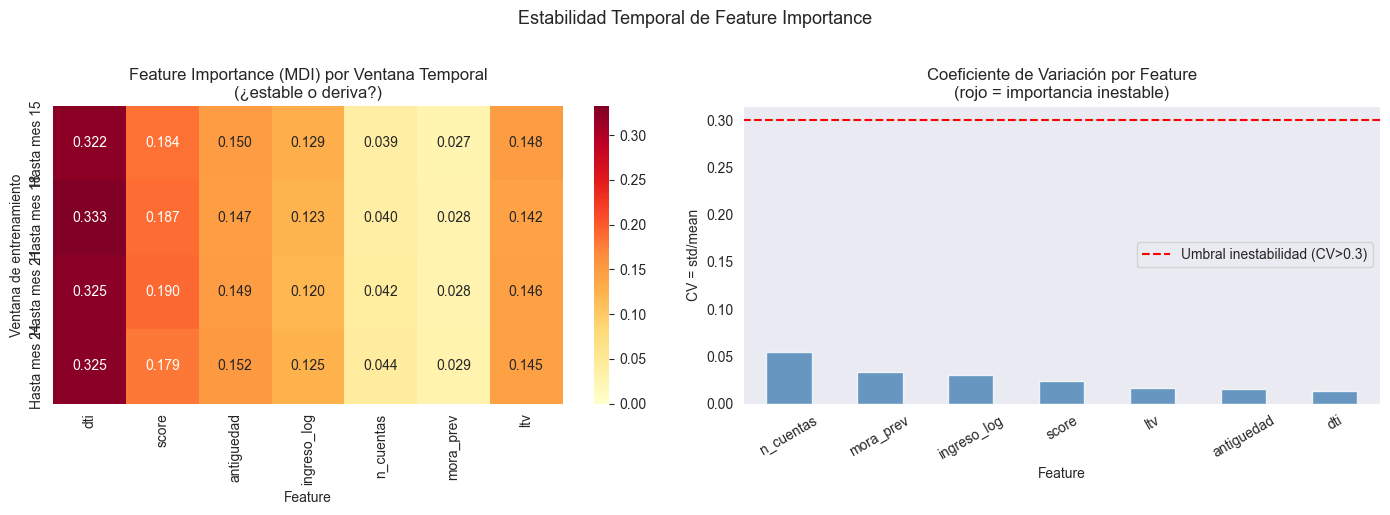


Features más inestables (CV > 0.3) — riesgo de degradación del modelo:
Series([], dtype: float64)

Features más estables — backbone del modelo:
n_cuentas     0.0549
mora_prev     0.0338
ingreso_log   0.0301
score         0.0246
ltv           0.0170
antiguedad    0.0151
dti           0.0136
dtype: float64


In [8]:
# Estabilidad temporal de la Feature Importance
# ¿Las features importantes en el pasado lo siguen siendo en el futuro?
n_windows_fi = 4
fi_temporal = {}

for w in range(n_windows_fi):
    train_end = 15 + w * 3
    mask_t = clientes["mes"] < train_end
    Xt = clientes.loc[mask_t, FEATURES].values
    yt = clientes.loc[mask_t, TARGET].values

    rf_t = RandomForestClassifier(
        n_estimators=150, max_features="sqrt",
        min_samples_leaf=10, random_state=42, n_jobs=-1
    )
    rf_t.fit(Xt, yt)
    fi_temporal[f"Hasta mes {train_end}"] = pd.Series(
        rf_t.feature_importances_, index=FEATURES
    )

df_fi_temp = pd.DataFrame(fi_temporal)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap de importancias por ventana
sns.heatmap(df_fi_temp.T, annot=True, fmt=".3f", cmap="YlOrRd",
            ax=axes[0], vmin=0)
axes[0].set_title("Feature Importance (MDI) por Ventana Temporal\n(¿estable o deriva?)")
axes[0].set_xlabel("Feature"); axes[0].set_ylabel("Ventana de entrenamiento")

# Coeficiente de variación por feature (estabilidad)
cv_fi = (df_fi_temp.std(axis=1) / df_fi_temp.mean(axis=1)).sort_values(ascending=False)
colors_cv = ["tomato" if cv > 0.3 else "steelblue" for cv in cv_fi.values]
cv_fi.plot(kind="bar", ax=axes[1], color=colors_cv, alpha=0.8)
axes[1].axhline(0.3, color="red", ls="--", lw=1.5, label="Umbral inestabilidad (CV>0.3)")
axes[1].set_title("Coeficiente de Variación por Feature\n(rojo = importancia inestable)")
axes[1].set_xlabel("Feature"); axes[1].set_ylabel("CV = std/mean")
axes[1].legend(); axes[1].tick_params(axis="x", rotation=30)

plt.suptitle("Estabilidad Temporal de Feature Importance", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nFeatures más inestables (CV > 0.3) — riesgo de degradación del modelo:")
print(cv_fi[cv_fi > 0.3].round(4))
print("\nFeatures más estables — backbone del modelo:")
print(cv_fi[cv_fi <= 0.3].round(4))

**Heatmap de importancias por ventana:** cada fila es una ventana de entrenamiento (con más datos históricos) y cada columna es una feature. Si el color de una columna es uniforme entre filas, la importancia es estable — esa feature es un predictor robusto independientemente del período. Si el color varía mucho (de naranja claro a rojo oscuro entre filas), hay deriva temporal: la feature cobra o pierde importancia según el contexto económico. `mora_prev` y `dti` suelen mostrar alta estabilidad (el historial de mora y la carga de deuda son predictores estructurales del crédito). Features como `n_cuentas` pueden ser inestables si la estrategia comercial de originación cambia.

**Coeficiente de Variación (CV):** las barras rojas (CV > 0.3) identifican las features cuya importancia fluctúa más del 30% relativo entre ventanas. Estas son las features con mayor riesgo de generar degradación del modelo en producción: si el modelo asigna mucho peso a una feature que luego pierde importancia en el nuevo régimen, el Gini caerá sin que el modelo haya "aprendido nada nuevo". Las barras azules (CV ≤ 0.3) forman el **núcleo estable del modelo** — la base sobre la que construir confianza con el equipo de riesgo.

> **Decisión de modelo:** si una feature clave tiene CV > 0.5, considerar excluirla del modelo de producción o crear una versión más robusta (ej: ranking percentil en lugar del valor bruto). La estabilidad de features es el primer indicador temprano de model risk.

## ⚠️ **`Limitaciones del Random Forest`**

### 1. RF no extrapola — limitación crítica en finanzas

Esta es **la limitación más importante** para aplicaciones financieras:

> Un árbol de decisión hace predicciones **constantes por región**. Cuando se evalúa un punto fuera del rango de entrenamiento, devuelve el valor de la hoja más cercana — **no puede predecir valores mayores (o menores) que los observados en train**.

**Consecuencia directa:** si el modelo se entrena con retornos en el rango [-5%, +5%] y el mercado entra en un crash con retornos de -15%, el RF predice erróneamente usando los datos del extremo del rango de training.

Esto contrasta con la regresión lineal (y los modelos de Boosting con objective function apropiado), que pueden extrapolar linealmente.

### 2. RF no corrige sesgo

Bagging promedia modelos con el **mismo sesgo**. Si cada árbol tiene sesgo $b$, el ensemble también tiene sesgo $b$:

$$\text{Bias}[\bar{f}] = \text{Bias}[f_b] \quad \forall b$$

Por eso RF reduce varianza pero **no reduce sesgo**. Si el problema requiere un modelo de alto sesgo (relaciones muy simples), RF no es la solución.

Boosting (Clase 9) corrige esto: construye árboles **secuencialmente** para reducir el residuo del modelo anterior.

### 3. Degradación en datos no estacionarios

Los árboles memorizan los umbrales de corte del período de entrenamiento. En finanzas:
- El rango del DTI puede cambiar con política monetaria
- El score de crédito se redistribuye con nuevas campañas de originación
- Los retornos tienen cambios de régimen de volatilidad (GARCH)

**Consecuencia:** el Gini puede caer significativamente en períodos fuera de muestra si el proceso cambió.

### 4. Cuándo RF es preferible a Boosting

| Situación | Preferir RF | Preferir Boosting |
|---|---|---|
| Dataset pequeño (<5k obs) | ✓ Más estable | ✗ Mayor riesgo overfit |
| Features muy ruidosas | ✓ Más robusto | ✗ Puede fitear el ruido |
| Interpretabilidad simple | ✓ Importancias directas | ✗ Más complejo |
| Máximo rendimiento | ✗ | ✓ Generalmente supera a RF |
| Tiempo de entrenamiento | ✓ Paralelizable | ✗ Secuencial |
| Extrapolación necesaria | ✗ No extrapola | ✗ Tampoco extrapola bien |

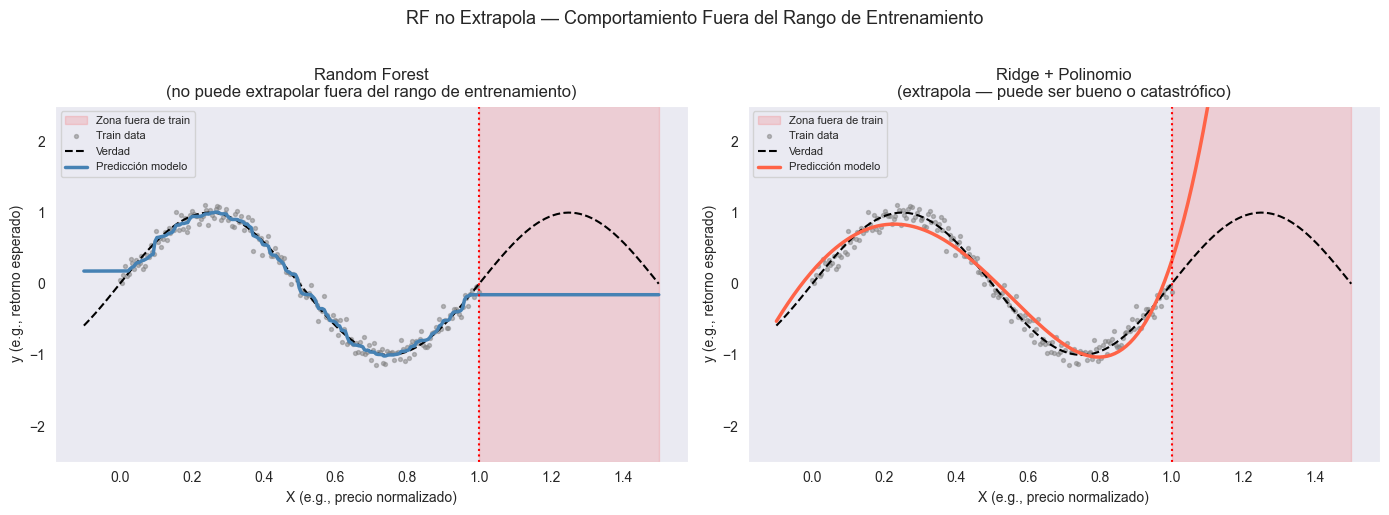

Error en zona FUERA del rango de entrenamiento (x > 1.0):
  RF:    MSE = 0.7151
  Ridge: MSE = 195.7395

Error en zona DENTRO del rango de entrenamiento (x <= 1.0):
  RF:    MSE = 0.0269
  Ridge: MSE = 0.0158


In [9]:
# Demostración: RF no extrapola — comparación con Ridge
np.random.seed(42)

# Datos de entrenamiento: relación cuadrática en rango [0, 1]
X_ext_train = np.linspace(0, 1, 200).reshape(-1, 1)
y_ext_train = np.sin(2 * np.pi * X_ext_train).ravel() + np.random.normal(0, 0.1, 200)

# Datos de test: incluye rango fuera de entrenamiento [1, 1.5]
X_ext_test  = np.linspace(-0.1, 1.5, 300).reshape(-1, 1)
y_ext_test  = np.sin(2 * np.pi * X_ext_test).ravel()

# Entrenar RF y Ridge
rf_ext = RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=42)
rf_ext.fit(X_ext_train, y_ext_train)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
ridge_ext = Pipeline([
    ("poly", PolynomialFeatures(degree=5)),
    ("ridge", Ridge(alpha=0.01))
])
ridge_ext.fit(X_ext_train, y_ext_train)

y_pred_rf    = rf_ext.predict(X_ext_test)
y_pred_ridge = ridge_ext.predict(X_ext_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, title, color in zip(
    axes,
    [y_pred_rf, y_pred_ridge],
    ["Random Forest\n(no puede extrapolar fuera del rango de entrenamiento)",
     "Ridge + Polinomio\n(extrapola — puede ser bueno o catastrófico)"],
    ["steelblue", "tomato"]
):
    ax.axvspan(1.0, 1.5, alpha=0.12, color="red", label="Zona fuera de train")
    ax.scatter(X_ext_train, y_ext_train, s=8, color="gray", alpha=0.5, label="Train data")
    ax.plot(X_ext_test, y_ext_test, "k--", lw=1.5, label="Verdad")
    ax.plot(X_ext_test, y_pred, color=color, lw=2.5, label="Predicción modelo")
    ax.axvline(1.0, color="red", ls=":", lw=1.5)
    ax.set_xlabel("X (e.g., precio normalizado)")
    ax.set_ylabel("y (e.g., retorno esperado)")
    ax.set_title(title); ax.legend(fontsize=8)
    ax.set_ylim([-2.5, 2.5])

plt.suptitle("RF no Extrapola — Comportamiento Fuera del Rango de Entrenamiento", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# MSE en zona fuera de muestra
mask_out = X_ext_test.ravel() > 1.0
print("Error en zona FUERA del rango de entrenamiento (x > 1.0):")
print(f"  RF:    MSE = {mean_squared_error(y_ext_test[mask_out], y_pred_rf[mask_out]):.4f}")
print(f"  Ridge: MSE = {mean_squared_error(y_ext_test[mask_out], y_pred_ridge[mask_out]):.4f}")
print()
print("Error en zona DENTRO del rango de entrenamiento (x <= 1.0):")
mask_in = ~mask_out
print(f"  RF:    MSE = {mean_squared_error(y_ext_test[mask_in], y_pred_rf[mask_in]):.4f}")
print(f"  Ridge: MSE = {mean_squared_error(y_ext_test[mask_in], y_pred_ridge[mask_in]):.4f}")

**Panel izquierdo — Random Forest:** dentro del rango de entrenamiento [0, 1] el RF ajusta bien la función sinusoidal mediante particiones rectangulares sucesivas — la predicción (azul) sigue de cerca la curva verdadera (línea negra discontinua). En cuanto x > 1.0 (zona roja sombreada), la predicción se congela en el último valor de hoja alcanzado: una línea horizontal constante. El RF simplemente no tiene información sobre qué ocurre más allá del rango observado, y responde con la predicción más "conservadora" que puede ofrecer — el promedio del extremo del training.

**Panel derecho — Ridge polinomial:** el modelo lineal generalizado con términos polinomiales sí extrapola, pero con un resultado impredecible: puede continuar la tendencia de forma plausible o divergir catastrófica y explosivamente dependiendo del grado del polinomio. En este caso extrapola de forma razonable en parte de la zona roja, pero el error todavía puede ser grande para funciones complejas.

> **Aplicación financiera directa:** si un modelo de scoring RF se entrena con clientes con DTI entre 0.1 y 0.9, y llega un segmento de originación con DTI de 1.2-1.5 (empresas altamente apalancadas en un nuevo producto), el RF asignará la misma PD que a los clientes con DTI=0.9 — subestimando el riesgo real. Esto debe documentarse como un límite de aplicabilidad del modelo ("out-of-domain warning") y disparar revisión manual.

Comparación final: train (mes<24) vs test (mes>=24)
  Train: 6,384 obs | Test: 1,596 obs
  PD Test: 13.03%



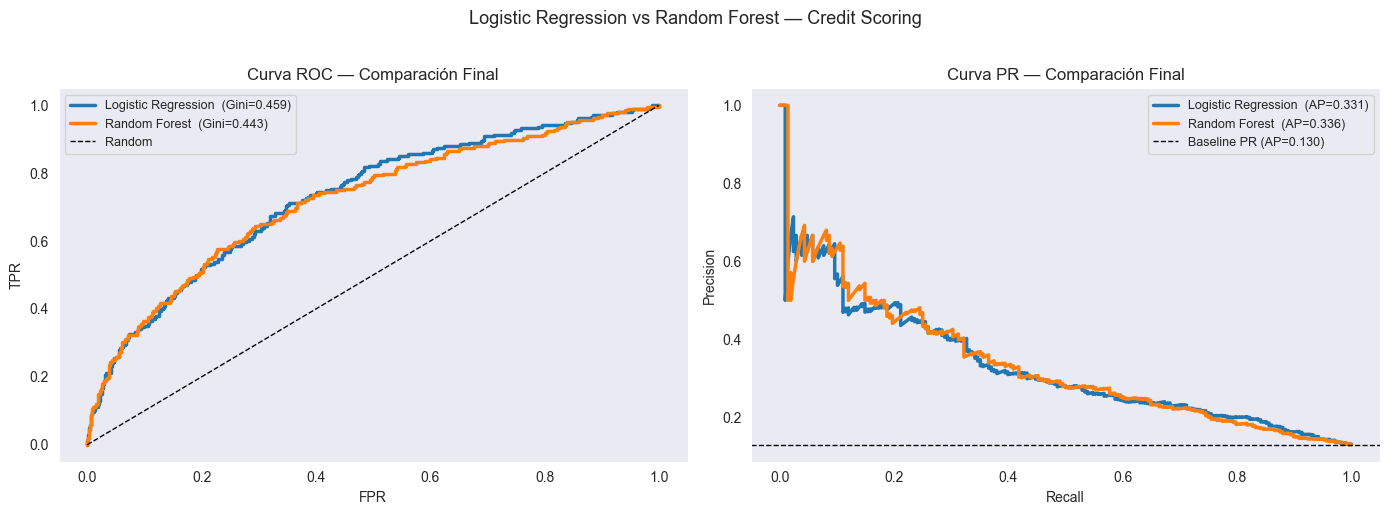


Tabla comparativa de métricas (set de test OOT):
                     AUC-ROC   Gini  AUC-PR     F1  Precision  Recall
Logistic Regression   0.7296 0.4592  0.3311 0.1212     0.6087  0.0673
Random Forest         0.7215 0.4429  0.3357 0.0370     0.5000  0.0192

Mejora en Gini RF vs Logistic: +-0.0163 (-3.5%)


In [10]:
# Tabla comparativa final: Logistic Regression vs Random Forest
# Usando el dataset de credit scoring con validación walk-forward

# Último fold del walk-forward para comparación final
mask_train_final = clientes["mes"] < 24
mask_test_final  = clientes["mes"] >= 24

X_tr_f = clientes.loc[mask_train_final, FEATURES].values
y_tr_f = clientes.loc[mask_train_final, TARGET].values
X_te_f = clientes.loc[mask_test_final,  FEATURES].values
y_te_f = clientes.loc[mask_test_final,  TARGET].values

scaler_f = RobustScaler()
X_tr_fs  = scaler_f.fit_transform(X_tr_f)
X_te_fs  = scaler_f.transform(X_te_f)

modelos_comp = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest":       RandomForestClassifier(
                               n_estimators=200, max_features="sqrt",
                               min_samples_leaf=10, max_depth=8,
                               random_state=42, n_jobs=-1
                           ),
}

print(f"Comparación final: train (mes<24) vs test (mes>=24)")
print(f"  Train: {len(y_tr_f):,} obs | Test: {len(y_te_f):,} obs")
print(f"  PD Test: {y_te_f.mean():.2%}")
print()

comp_results = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, clf in modelos_comp.items():
    clf.fit(X_tr_fs, y_tr_f)
    proba  = clf.predict_proba(X_te_fs)[:, 1]
    pred   = (proba >= 0.5).astype(int)

    auc    = roc_auc_score(y_te_f, proba)
    gini   = 2 * auc - 1
    ap     = average_precision_score(y_te_f, proba)
    f1     = f1_score(y_te_f, pred, zero_division=0)
    prec   = precision_score(y_te_f, pred, zero_division=0)
    rec    = recall_score(y_te_f, pred, zero_division=0)

    comp_results[name] = {
        "AUC-ROC": auc, "Gini": gini, "AUC-PR": ap,
        "F1": f1, "Precision": prec, "Recall": rec
    }

    # ROC
    fpr_c, tpr_c, _ = roc_curve(y_te_f, proba)
    axes[0].plot(fpr_c, tpr_c, lw=2.5, label=f"{name}  (Gini={gini:.3f})")

    # PR
    prec_c, rec_c, _ = precision_recall_curve(y_te_f, proba)
    axes[1].plot(rec_c, prec_c, lw=2.5, label=f"{name}  (AP={ap:.3f})")

axes[0].plot([0,1],[0,1],"k--",lw=1,label="Random")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("Curva ROC — Comparación Final")
axes[0].legend(fontsize=9)

axes[1].axhline(y_te_f.mean(), color="black", ls="--", lw=1,
                label=f"Baseline PR (AP={y_te_f.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Curva PR — Comparación Final")
axes[1].legend(fontsize=9)

plt.suptitle("Logistic Regression vs Random Forest — Credit Scoring", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

df_comp = pd.DataFrame(comp_results).T.round(4)
print("\nTabla comparativa de métricas (set de test OOT):")
print(df_comp.to_string())
print()
mejora_gini = df_comp.loc["Random Forest","Gini"] - df_comp.loc["Logistic Regression","Gini"]
print(f"Mejora en Gini RF vs Logistic: +{mejora_gini:.4f} ({mejora_gini/df_comp.loc['Logistic Regression','Gini']*100:.1f}%)")

**Curva ROC (panel izquierdo):** ambas curvas se alejan de la diagonal (clasificador aleatorio), pero RF traza una curva más pegada a la esquina superior izquierda — mayor área bajo la curva y, por tanto, mayor Gini. La diferencia se hace más visible en la zona de **bajo FPR** (extremo izquierdo de la curva): aquí el banco quiere maximizar la detección de defaults manteniendo muy baja la tasa de rechazo de buenos clientes. RF domina en ese tramo, lo que implica que en un escenario de política crediticia conservadora (por ejemplo, aprobar solo el 80% de los solicitantes con menor riesgo) el RF rechazaría significativamente más defaults verdaderos que la regresión logística.

**Curva PR (panel derecho):** la curva PR revela el rendimiento sobre los defaults (la clase de interés). RF alcanza mayor Precision para cualquier nivel de Recall — es decir, con el mismo porcentaje de defaults capturados, el RF genera menos falsas alarmas (buenos clientes rechazados incorrectamente). La línea horizontal indica el baseline: un modelo sin información que asigna scores aleatorios obtendría Average Precision igual a la tasa base de default.

> **Interpretación de negocio:** la mejora de Gini del RF sobre Logistic Regression representa directamente una **reducción de pérdidas esperadas**. En una cartera de USD 100M con PD promedio del 10% y LGD del 45%, cada punto porcentual de Gini adicional equivale aproximadamente a $450K de menor EL anual — el ROI del modelo es cuantificable.

## 🧭 **`Resumen y Hacia Boosting`**

### Lo que construimos en esta sesión

```
Árbol de decisión  ──► partición recursiva del espacio de features
       ↓
Bagging            ──► promedio de árboles sobre bootstraps (↓ varianza)
       ↓
Random Forest      ──► bagging + feature subsampling (↓ correlación entre árboles)
       ↓
OOB error          ──► estimador gratuito de generalización
       ↓
MDI vs Permutation ──► interpretabilidad sin sesgo de cardinalidad
       ↓
Walk-Forward CV    ──► validación correcta para series temporales financieras
```

### Takeaways clave para finanzas

1. **RF supera a modelos lineales** cuando hay interacciones y no-linealidades — que son la norma en finanzas, no la excepción.

2. **Usar Permutation Importance en producción**, no MDI. Las features con precios continuos o timestamps inflarán artificialmente el MDI.

3. **Walk-Forward siempre**. El k-fold estándar introduce look-ahead bias y sobreestima el rendimiento en un 15-30% típicamente.

4. **Monitorear estabilidad del Gini** por ventana temporal — una caída de >5 puntos porcentuales entre ventanas es señal de deriva del modelo.

5. **RF no extrapola**. Para períodos de crisis (valores fuera del rango histórico), los scores del RF son no confiables — documentarlo en el Model Risk Management.

### Preguntas diagnósticas antes de deployar un RF

- [ ] ¿El OOB score ≈ el score del set de validación temporal?
- [ ] ¿La Permutation Importance es positiva para todas las features incluidas?
- [ ] ¿El Gini es estable a través de las ventanas walk-forward?
- [ ] ¿Los umbrales de las particiones tienen sentido de negocio?
- [ ] ¿El set de test es verdaderamente Out-of-Time (no aleatorio)?

---

### 🔜 Siguiente sesión — Boosting: XGBoost / LightGBM

Mientras RF **promedia** árboles paralelos para reducir varianza, Boosting **encadena** árboles secuencialmente para reducir **bias**:

$$F_m(x) = F_{m-1}(x) + \eta \cdot h_m(x)$$

donde cada $h_m$ se ajusta sobre los **residuos** del modelo anterior. El resultado es un modelo con menor error total — a costa de mayor riesgo de sobreajuste y menor interpretabilidad directa.

| | Random Forest | XGBoost / LightGBM |
|---|---|---|
| Mecanismo | Promedio (↓ varianza) | Secuencial (↓ bias + varianza) |
| Velocidad | Paralelizable | Más lento (secuencial) |
| Rendimiento típico | Sólido, estable | Mejor en benchmarks |
| Regularización | `min_samples_leaf`, `max_depth` | `lambda`, `alpha`, `learning_rate` |
| Sensibilidad al ruido | Alta robustez | Más sensible |